# Análise Exploratória de Recursos Humanos (Base HR - FreeSQL)

**Disciplina:** Visualização de Dados e Business Intelligence [T3] <br>
**Instituição:** SENAI / SCTEC — Módulo 1 <br>
**Autor:** Dilsonei José Rigotti <br>
**Orientadora:** Cibelle Maciel <br>
**Turma:** Carreira Tech - Trilha Análise de Dados - SCTEC / SENAI <br>

---

## 🎯 Objetivo do Estudo
Este notebook apresenta a análise exploratória dos dados de Recursos Humanos obtidos a partir do esquema **HR** via FreeSQL (Oracle Database).

O objetivo é diagnosticar a equidade salarial, identificar disparidades entre departamentos e entender a concentração geográfica da força de trabalho para apoiar tomadas de decisão estratégicas de gestão de pessoas.

## 1. Consultas SQL Desenvolvidas no FreeSQL

Para extrair os dados analíticos necessários da base relacional Oracle **HR**, foram construídas duas consultas SQL estratégicas aplicando `LEFT JOIN` e filtros com cláusula `WHERE`.

### 🔹 Consulta 1: Salários por Departamento e Cargo (`sql/query_1.sql`)
- **Objetivo:** Relacionar cada colaborador ao seu respectivo departamento e cargo cadastrado, permitindo avaliar faixas e dispersão salarial.
- **Relacionamentos:** `HR.EMPLOYEES` cruzando com `HR.DEPARTMENTS` e `HR.JOBS`.
- **Filtro Aplicado:** `WHERE e.DEPARTMENT_ID IS NOT NULL` (elimina registros sem departamento alocado para não enviesar médias setoriais).
- **Arquivo Gerado:** `CSV/query_01.csv`

```sql
SELECT 
    e.EMPLOYEE_ID,
    e.FIRST_NAME,
    e.LAST_NAME,
    e.SALARY,
    d.DEPARTMENT_ID,
    d.DEPARTMENT_NAME,
    j.JOB_ID,
    j.JOB_TITLE,
    j.MIN_SALARY,
    j.MAX_SALARY
FROM HR.EMPLOYEES e
LEFT JOIN HR.DEPARTMENTS d 
    ON e.DEPARTMENT_ID = d.DEPARTMENT_ID
LEFT JOIN HR.JOBS j 
    ON e.JOB_ID = j.JOB_ID
WHERE e.DEPARTMENT_ID IS NOT NULL
ORDER BY e.SALARY DESC;
```

---

### 🔹 Consulta 2: Funcionários por Região Geográfica (`sql/query_2.sql`)
- **Objetivo:** Mapear a força de trabalho conectando o colaborador até a região continental de seu escritório de lotação.
- **Relacionamentos:** Encadeamento de 4 `LEFT JOIN`s: `HR.EMPLOYEES` ➔ `HR.DEPARTMENTS` ➔ `HR.LOCATIONS` ➔ `HR.COUNTRIES` ➔ `HR.REGIONS`.
- **Filtro Aplicado:** `WHERE r.REGION_NAME IS NOT NULL`.
- **Arquivo Gerado:** `CSV/query_02.csv`

```sql
SELECT 
    e.EMPLOYEE_ID,
    e.FIRST_NAME,
    e.LAST_NAME,
    e.SALARY,
    d.DEPARTMENT_NAME,
    l.CITY,
    l.STATE_PROVINCE,
    c.COUNTRY_NAME,
    r.REGION_NAME
FROM HR.EMPLOYEES e
LEFT JOIN HR.DEPARTMENTS d 
    ON e.DEPARTMENT_ID = d.DEPARTMENT_ID
LEFT JOIN HR.LOCATIONS l 
    ON d.LOCATION_ID = l.LOCATION_ID
LEFT JOIN HR.COUNTRIES c 
    ON l.COUNTRY_ID = c.COUNTRY_ID
LEFT JOIN HR.REGIONS r 
    ON c.REGION_ID = r.REGION_ID
WHERE r.REGION_NAME IS NOT NULL
ORDER BY r.REGION_NAME, e.SALARY DESC;
```

## 2. Importação das Bibliotecas e Configuração do Ambiente

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

## 3. Carregamento dos Arquivos CSV Exportados

Leitura dos arquivos `.csv` gerados a partir do FreeSQL e validação do volume de registros.

> 📌 **Nota:**  
> Por padrão, o FreeSQL e o navegador exportam os arquivos como `export*.csv`. Para manter o projeto alinhado aos scripts SQL (`query_1.sql` e `query_2.sql`), os arquivos "*.csv" foram renomeados manualmente para **`query_01.csv`** e **`query_02.csv`**. Os arquivos originais foram preservados localmente, porém adicionados ao `.gitignore`.

In [25]:
# Tratamento de caminho para rodar tanto na raiz quanto na pasta /notebooks
path_q1 = "CSV/query_01.csv" if os.path.exists("CSV/query_01.csv") else "../CSV/query_01.csv"
path_q2 = "CSV/query_02.csv" if os.path.exists("CSV/query_02.csv") else "../CSV/query_02.csv"

df_dept = pd.read_csv(path_q1)
df_regiao = pd.read_csv(path_q2)

print(f"✓ Query 1 carregada: {len(df_dept)} registros")
print(f"✓ Query 2 carregada: {len(df_regiao)} registros")
df_dept.head()

✓ Query 1 carregada: 106 registros
✓ Query 2 carregada: 106 registros


,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,SALARY,DEPARTMENT_ID,DEPARTMENT_NAME,JOB_ID,JOB_TITLE,MIN_SALARY,MAX_SALARY
0,100,Steven,King,24000,90,Executive,AD_PRES,President,20080,40000
1,101,Neena,Yang,17000,90,Executive,AD_VP,Administration Vice President,15000,30000
2,102,Lex,Garcia,17000,90,Executive,AD_VP,Administration Vice President,15000,30000
3,145,John,Singh,14000,80,Sales,SA_MAN,Sales Manager,10000,20080
4,146,Karen,Partners,13500,80,Sales,SA_MAN,Sales Manager,10000,20080


## 4. Análise da Distribuição Geral de Salários

Comparação entre **Média** e **Mediana** para avaliar a assimetria da curva salarial da empresa.

In [26]:
media = df_dept["SALARY"].mean()
mediana = df_dept["SALARY"].median()
menor_salario = df_dept["SALARY"].min()
maior_salario = df_dept["SALARY"].max()
diff = media - mediana

print("=" * 40)
print("RESUMO ESTATÍSTICO DE REMUNERAÇÃO")
print("=" * 40)
print(f"Média Salarial:   $ {media:,.2f}")
print(f"Mediana Salarial: $ {mediana:,.2f}")
print(f"Menor Salário:    $ {menor_salario:,.2f}")
print(f"Maior Salário:    $ {maior_salario:,.2f}")
print(f"Diferença (Média - Mediana): $ {diff:,.2f}")
print("=" * 40)

if diff > 0:
    print('💡 Diagnóstico: A média é sensivelmente maior que a mediana devido aos salários da alta liderança (Executive), que "puxam" o valor para cima (assimetria positiva).')

RESUMO ESTATÍSTICO DE REMUNERAÇÃO
Média Salarial:   $ 6,456.75
Mediana Salarial: $ 6,150.00
Menor Salário:    $ 2,100.00
Maior Salário:    $ 24,000.00
Diferença (Média - Mediana): $ 306.75
💡 Diagnóstico: A média é sensivelmente maior que a mediana devido aos salários da alta liderança (Executive), que "puxam" o valor para cima (assimetria positiva).


### Gráfico 1: Histograma de Distribuição Salarial
Visualização da frequência salarial com indicação visual da média e da mediana.

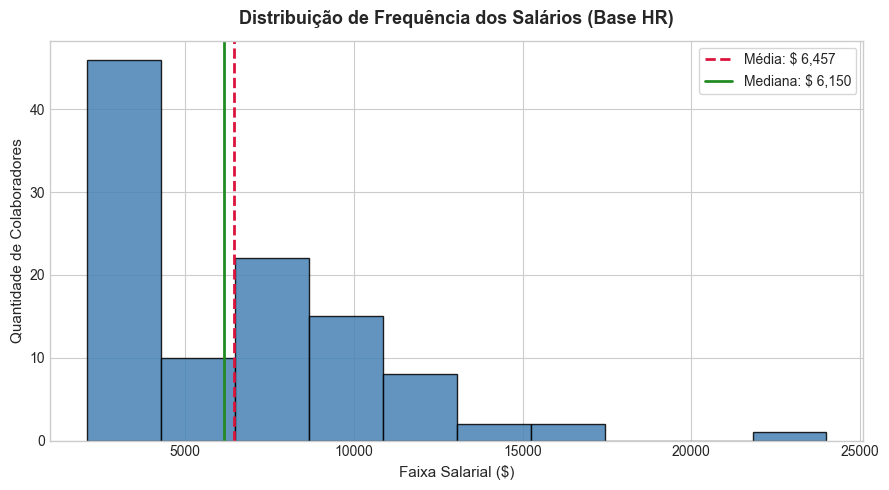

In [27]:
plt.figure(figsize=(9, 5))
plt.hist(df_dept["SALARY"], bins=10, color="steelblue", edgecolor="black", alpha=0.85)
plt.axvline(media, color="crimson", linestyle="--", linewidth=2, label=f"Média: $ {media:,.0f}")
plt.axvline(mediana, color="forestgreen", linestyle="-", linewidth=2, label=f"Mediana: $ {mediana:,.0f}")

plt.title("Distribuição de Frequência dos Salários (Base HR)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Faixa Salarial ($)", fontsize=11)
plt.ylabel("Quantidade de Colaboradores", fontsize=11)
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

## 5. Análise de Salários por Departamento

Agrupamento com métricas essenciais (contagem, média, mediana, mínimo e máximo) para identificar os setores mais valorizados financeiramente.

In [28]:
dept_resumo = df_dept.groupby("DEPARTMENT_NAME")["SALARY"].agg(["count", "mean", "median", "min", "max"])
dept_resumo = dept_resumo.rename(columns={
    "Colaboradores": "Colaboradores",
    "mean": "Média ($)",
    "median": "Mediana ($)",
    "min": "Mínimo ($)",
    "max": "Máximo ($)"
}).sort_values(by="Média ($)", ascending=False)

dept_resumo.round(2)

,count,Média ($),Mediana ($),Mínimo ($),Máximo ($)
DEPARTMENT_NAME,,,,,
Executive,3,19333.33,17000.0,17000,24000
Accounting,2,10154.00,10154.0,8300,12008
Public Relations,1,10000.00,10000.0,10000,10000
Marketing,2,9500.00,9500.0,6000,13000
Sales,34,8955.88,8900.0,6100,14000
Finance,6,8601.33,8000.0,6900,12008
Human Resources,1,6500.00,6500.0,6500,6500
IT,5,5760.00,4800.0,4200,9000
Administration,1,4400.00,4400.0,4400,4400


### Gráfico 2: Boxplot dos Salários por Departamento
Análise de dispersão e identificação de assimetrias e dispersão nos principais departamentos (>= 3 colaboradores), em um gráfico estatístico muito utilizado na Ciência de Dados e no BI.

Em vez de mostrar apenas uma média (que pode enganar), o boxplot mostra como os salários estão espalhados de ponta a ponta.

O que cada pedaço significa:

A Caixa (O miolo):  
Representa os 50% centrais dos colaboradores (do percentil 25% até 75%).  
Se a caixa for baixa/achatada, significa que quase todo mundo naquele setor ganha salários muito parecidos.  
Se a caixa for alta/alongada, significa que há uma grande diferença salarial dentro daquele departamento.  

A Linha no meio da caixa (Mediana):   
É o salário da pessoa que está exatamente no meio da fila.  
Se a linha estiver perto da base da caixa, significa que a maioria ganha menos e poucos ganham mais.  

As Hastes ("Bigodes"):  
Mostram o alcance do menor salário e do maior salário dentro do esperado.  

Pontinhos soltos fora das hastes (Outliers):  
São valores muito fora do padrão (exemplo: um único funcionário ou diretor que ganha muito acima de todo o resto).  



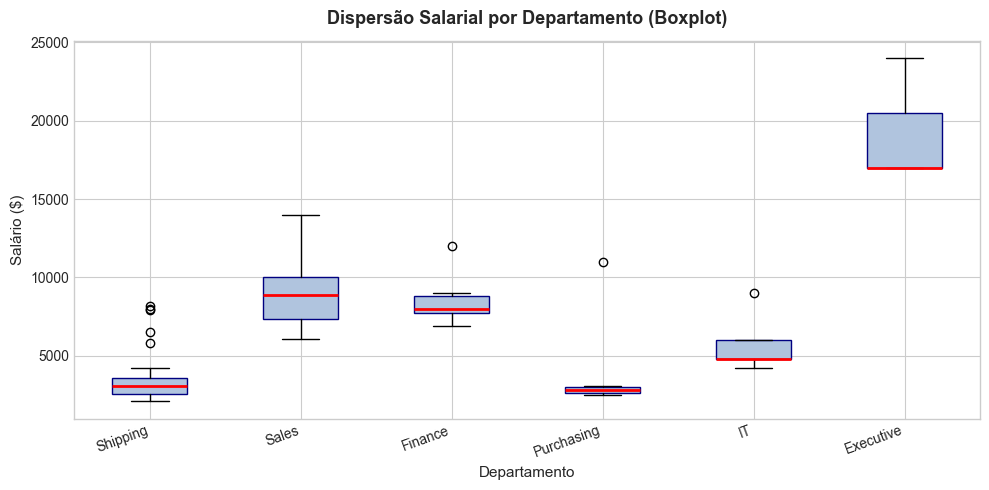

In [29]:
principais_depts = df_dept["DEPARTMENT_NAME"].value_counts()[lambda x: x >= 3].index
dados_filtrados = df_dept[df_dept["DEPARTMENT_NAME"].isin(principais_depts)]

dados_grafico = [dados_filtrados[dados_filtrados["DEPARTMENT_NAME"] == d]["SALARY"] for d in principais_depts]

plt.figure(figsize=(10, 5))
plt.boxplot(dados_grafico, tick_labels=principais_depts, patch_artist=True,
            boxprops=dict(facecolor="lightsteelblue", color="navy"),
            medianprops=dict(color="red", linewidth=2))

plt.title("Dispersão Salarial por Departamento (Boxplot)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Departamento", fontsize=11)
plt.ylabel("Salário ($)", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Distribuição Geográfica e Regional

Avaliação de como a empresa está distribuída internacionalmente e comparação de salários por continente. 

A empresa possui uma operação fortemente centralizada na matriz americana, onde ficam a sede administrativa (Executive), a tecnologia (IT) e toda a logística de base (Shipping).  

A Europa tem uma média salarial consideravelmente maior que a das Américas, pois a filial europeia opera como um escritório especializado de Vendas (Sales), composto por profissionais seniores e gerentes.

Já as Américas concentram todo o piso operacional, incluindo Shipping (que tem mais de 40 pessoas com os menores salários).

Conclusão: A Europa não paga "melhor" por privilégio regional, mas sim porque sua equipe é exclusivamente técnica/comercial, enquanto as Américas diluem sua média com os operacionais de fábrica/expedição.

In [30]:
regiao_resumo = df_regiao.groupby("REGION_NAME")["SALARY"].agg(["count", "mean", "median", "min", "max"])
regiao_resumo = regiao_resumo.rename(columns={
    "count": "Colaboradores",
    "mean": "Média ($)",
    "median": "Mediana ($)",
    "min": "Mínimo ($)",
    "max": "Máximo ($)"
})

regiao_resumo.round(2)

,Colaboradores,Média ($),Mediana ($),Mínimo ($),Máximo ($)
REGION_NAME,,,,,
Americas,70,5191.66,3300.0,2100,24000
Europe,36,8916.67,8900.0,6100,14000


### Gráfico 3: Força de Trabalho por Região

O que o gráfico mostra:  

A maioria dos colaboradores (cerca de 70%) está concentrada na região das Américas (EUA e Canadá), enquanto a Europa possui um contingente menor (cerca de 30%).

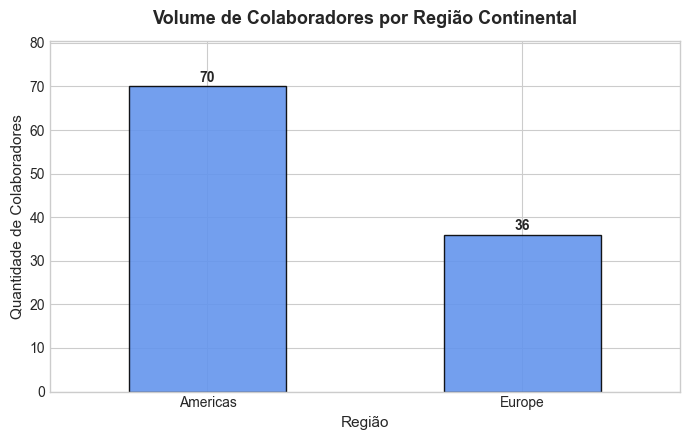

In [31]:
plt.figure(figsize=(7, 4.5))
contagem_regioes = df_regiao["REGION_NAME"].value_counts()
barras = contagem_regioes.plot(kind="bar", color="cornflowerblue", edgecolor="black", alpha=0.9)

for i, v in enumerate(contagem_regioes):
    plt.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.title("Volume de Colaboradores por Região Continental", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Região", fontsize=11)
plt.ylabel("Quantidade de Colaboradores", fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0, max(contagem_regioes) * 1.15)
plt.tight_layout()
plt.show()

## 7. Principais Resultados e Insights de RH

1. **Alta concentração salarial em funções operacionais:** Mais de 42% de todo o quadro da empresa está alocado no setor de *Shipping* (logística/expedição), com média salarial em torno de $ 3.475,00.
2. **Disparidade entre unidades geográficas:** A filial europeia apresenta uma remuneração média 71% superior à americana, não por política discriminatória, mas pela natureza funcional dos escritórios (a Europa concentra a força comercial/vendas, enquanto as Américas abrigam a fábrica/logística e a diretoria).
3. **Limitação para tomada de decisão:** A amostra da base HR não contempla tempo de casa, horas extras, comissões variáveis efetivamente pagas no mês, moeda local e custo de vida de cada país. Qualquer política salarial deve considerar esses fatores externos antes de ajustes de piso ou plano de carreira.